In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Usiamo 2 feature per classificare un tumore:
#   x1 = dimensione del tumore (raggio medio della massa)
#   x2 = irregolarità del contorno (quanto è frastagliato)
# Obiettivo: stimare P(y = 1) = probabilità che il tumore sia MALIGNO.
#   y = 0 -> BENIGNO   |   y = 1 -> MALIGNO
n_per_classe = 50

# TUMORI BENIGNI (classe 0): piccoli e regolari -> nuvola centrata in (2, 2)
X_benigni = np.random.randn(n_per_classe, 2) * 1.5 + np.array([2, 2])

# TUMORI MALIGNI (classe 1): grandi e irregolari -> nuvola centrata in (6, 6)
X_maligni = np.random.randn(n_per_classe, 2) * 1.5 + np.array([6, 6])

# Matrice delle feature: prima i benigni, poi i maligni (shape: 100 x 2)
X = np.vstack((X_benigni, X_maligni))

# Etichette: 0 = benigno, 1 = maligno (shape: 100 x 1)
y = np.array([0] * n_per_classe + [1] * n_per_classe).reshape(-1, 1)

print(f"Shape della matrice delle feature X: {X.shape}")
print(f"Shape del vettore delle etichette y: {y.shape}")
print(f"Classi: 0 = benigno, 1 = maligno -> presenti: {np.unique(y)}")

Shape della matrice delle feature X: (100, 2)
Shape del vettore delle etichette y: (100, 1)
Classi: 0 = benigno, 1 = maligno -> presenti: [0 1]


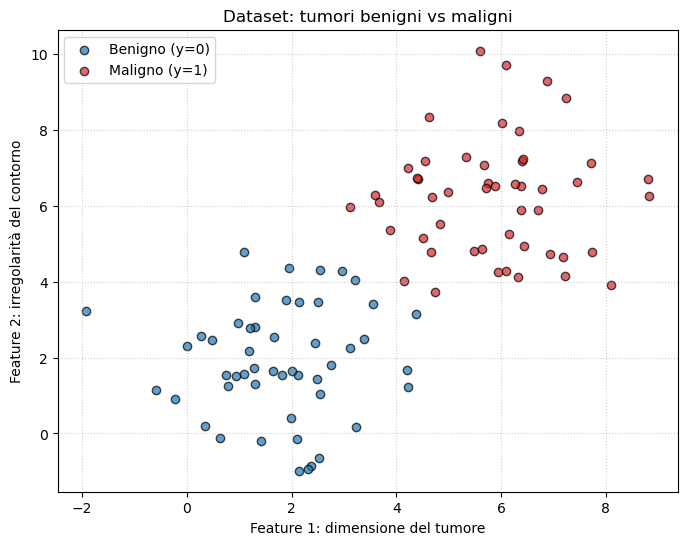

In [2]:
# Separo i punti per classe usando una "maschera booleana":
# y[:, 0] == 0 produce un array di True/False, che uso per selezionare le righe di X
benigni = X[y[:, 0] == 0]
maligni = X[y[:, 0] == 1]

plt.figure(figsize=(8, 6))
plt.scatter(benigni[:, 0], benigni[:, 1],
          color='#1f77b4', edgecolors='k', alpha=0.7, label='Benigno (y=0)')
plt.scatter(maligni[:, 0], maligni[:, 1],
          color='#d62728', edgecolors='k', alpha=0.7, label='Maligno (y=1)')

plt.xlabel('Feature 1: dimensione del tumore')
plt.ylabel('Feature 2: irregolarità del contorno')
plt.title('Dataset: tumori benigni vs maligni')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

In [3]:
# Sigmoide
def g(z):
  """Funzione logistica (sigmoide) di Ng: g(z) = 1 / (1 + e^{-z}). Schiaccia z in (0, 1)."""
  return 1 / (1 + np.exp(-z))

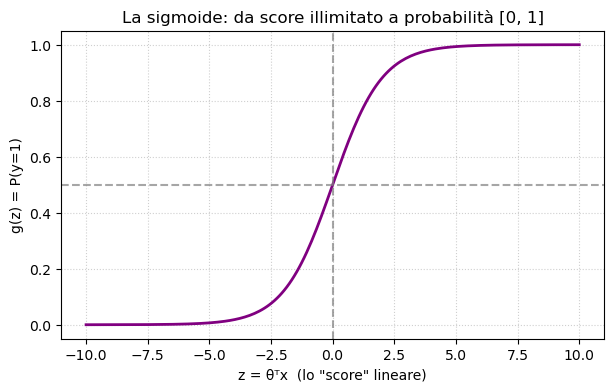

In [4]:
z = np.linspace(-10, 10, 200)

plt.figure(figsize=(7, 4))
plt.plot(z, g(z), color='purple', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7)  # soglia di decisione
plt.axvline(0, color='gray', linestyle='--', alpha=0.7)    # dove z = 0
plt.xlabel('z = θᵀx  (lo "score" lineare)')
plt.ylabel('g(z) = P(y=1)')
plt.title('La sigmoide: da score illimitato a probabilità [0, 1]')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [7]:
# Notazione CS229: m esempi, n feature, trucco dell'intercetta x0 = 1.
m = X.shape[0]   # numero di esempi (100)
n = X.shape[1]   # numero di feature (2: dimensione e irregolarità)

# Design matrix: antepongo una colonna di 1 (la x0) -> shape (m, n+1) = (100, 3)
X_b = np.hstack([np.ones((m, 1)), X])
print(f"Shape della design matrix X_b: {X_b.shape}")

# theta ha ORA TRE componenti:
#   theta0 = bias | theta1 = peso della dimensione | theta2 = peso dell'irregolarità
theta = np.zeros((n + 1, 1))   # shape (3, 1)
print(f"theta iniziale (theta0, theta1, theta2): {theta.ravel()}")

Shape della design matrix X_b: (100, 3)
theta iniziale (theta0, theta1, theta2): [0. 0. 0.]


In [8]:
def ipotesi(X_b, theta):
  """
  Ipotesi della logistic regression (CS229): h_theta(x) = g(theta^T x).
  È ESATTAMENTE l'ipotesi lineare theta^T x dei notebook precedenti (X_b @ theta),
  ma 'avvolta' nella sigmoide g per trasformare lo score in una probabilità P(y=1|x).
  """
  return g(X_b @ theta)


# Con theta = 0 lo score theta^T x vale 0 per ogni esempio, e g(0) = 0.5:
# il modello parte 'indeciso', assegna 50% di probabilità di maligno a tutti.
print(f"Prime 5 probabilità predette con theta = 0:\n{ipotesi(X_b, theta)[:5].ravel()}")

Prime 5 probabilità predette con theta = 0:
[0.5 0.5 0.5 0.5 0.5]


In [9]:
def costo_J(X_b, y, theta):
  """
  Costo log-loss = negative log-likelihood (CS229):
      J(theta) = -(1/m) * somma_i [ y_i*log(h_i) + (1-y_i)*log(1-h_i) ]
  Minimizzare J equivale a massimizzare la log-verosimiglianza ell(theta) di Ng.
  """
  h = ipotesi(X_b, theta)
  eps = 1e-9   # evita log(0) se h vale esattamente 0 o 1
  return -(1 / m) * np.sum(y * np.log(h + eps) + (1 - y) * np.log(1 - h + eps))


print(f"Costo iniziale J(theta) con theta = 0: {costo_J(X_b, y, theta):.4f}")

Costo iniziale J(theta) con theta = 0: 0.6931


In [10]:
# Iperparametri
alpha = 0.1
iterazioni = 3000

storia_costo = []

print("Inizio l'addestramento (logistic regression, Batch Gradient Descent)...")
print("-" * 62)

for iterazione in range(iterazioni):
  # 1. Ipotesi: probabilità predette su tutti gli esempi -> h = g(X_b @ theta)
  h = ipotesi(X_b, theta)

  # 2. Gradiente della log-loss: STESSA forma del GD lineare!
  #    (il termine non-lineare della sigmoide si semplifica nella derivata)
  gradiente = (1 / m) * (X_b.T @ (h - y))   # shape (n+1, 1) = (3, 1)

  # 3. Aggiornamento: theta := theta - alpha * gradiente
  theta = theta - alpha * gradiente

  costo_corrente = costo_J(X_b, y, theta)
  storia_costo.append(costo_corrente)

  if iterazione % 300 == 0 or iterazione == iterazioni - 1:
      print(f"Iter {iterazione:4d} -> J(theta): {costo_corrente:.4f} | theta: {theta.ravel().round(3)}")

print("-" * 62)
print(f"Parametri finali theta (theta0, theta1, theta2): {theta.ravel().round(4)}")

Inizio l'addestramento (logistic regression, Batch Gradient Descent)...
--------------------------------------------------------------
Iter    0 -> J(theta): 0.5813 | theta: [0.    0.102 0.108]
Iter  300 -> J(theta): 0.1968 | theta: [-3.151  0.507  0.421]
Iter  600 -> J(theta): 0.1343 | theta: [-4.486  0.675  0.567]
Iter  900 -> J(theta): 0.1078 | theta: [-5.361  0.783  0.667]
Iter 1200 -> J(theta): 0.0926 | theta: [-6.025  0.863  0.745]
Iter 1500 -> J(theta): 0.0825 | theta: [-6.567  0.929  0.809]
Iter 1800 -> J(theta): 0.0752 | theta: [-7.029  0.985  0.865]
Iter 2100 -> J(theta): 0.0696 | theta: [-7.432  1.033  0.913]
Iter 2400 -> J(theta): 0.0652 | theta: [-7.792  1.077  0.957]
Iter 2700 -> J(theta): 0.0615 | theta: [-8.119  1.116  0.996]
Iter 2999 -> J(theta): 0.0584 | theta: [-8.417  1.152  1.032]
--------------------------------------------------------------
Parametri finali theta (theta0, theta1, theta2): [-8.417   1.1525  1.0325]


In [11]:
# Predizione: 'maligno' (1) se probabilità >= 0.5, altrimenti 'benigno' (0)
probabilita = ipotesi(X_b, theta)
predizioni = (probabilita >= 0.5).astype(int)

# Accuracy = frazione di tumori classificati correttamente
accuracy = np.mean(predizioni == y)
print(f"Accuracy sul training set: {accuracy * 100:.1f}%")
print(f"Classificati correttamente: {int(np.sum(predizioni == y))} su {m}")

Accuracy sul training set: 100.0%
Classificati correttamente: 100 su 100


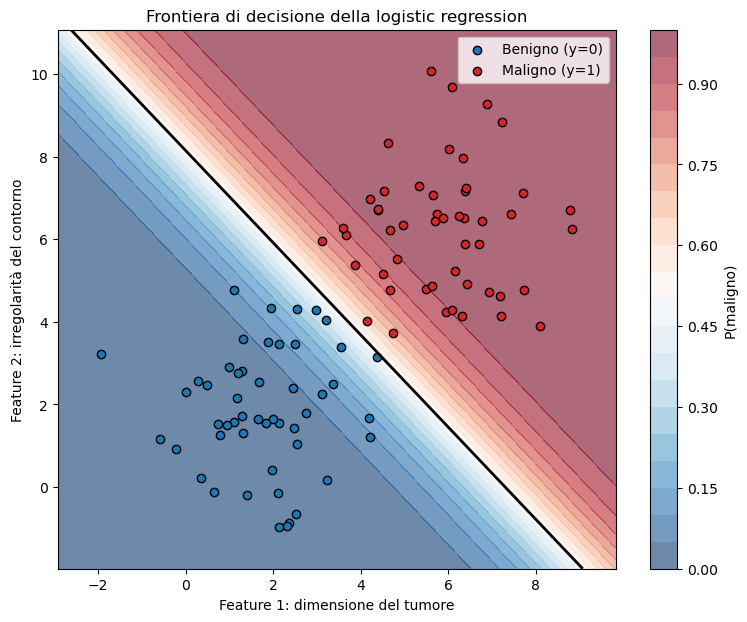

In [12]:
# Griglia fitta di punti sul piano per colorare lo sfondo con la probabilità predetta
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                     np.linspace(x2_min, x2_max, 200))

# Per ogni punto della griglia calcolo h_theta = g(theta^T x). Aggiungo la colonna x0 = 1.
griglia = np.c_[np.ones(xx1.size), xx1.ravel(), xx2.ravel()]
prob_griglia = ipotesi(griglia, theta).reshape(xx1.shape)

plt.figure(figsize=(9, 7))
# Sfondo: probabilità di maligno (blu = benigno ~0, rosso = maligno ~1)
sfondo = plt.contourf(xx1, xx2, prob_griglia, levels=20, cmap='RdBu_r', alpha=0.6)
plt.colorbar(sfondo, label='P(maligno)')

# La FRONTIERA DI DECISIONE: la linea dove P = 0.5 (cioè theta^T x = 0)
plt.contour(xx1, xx2, prob_griglia, levels=[0.5], colors='black', linewidths=2)

# I dati veri sopra
benigni = X[y[:, 0] == 0]
maligni = X[y[:, 0] == 1]
plt.scatter(benigni[:, 0], benigni[:, 1], color='#1f77b4', edgecolors='k', label='Benigno (y=0)')
plt.scatter(maligni[:, 0], maligni[:, 1], color='#d62728', edgecolors='k', label='Maligno (y=1)')

plt.xlabel('Feature 1: dimensione del tumore')
plt.ylabel('Feature 2: irregolarità del contorno')
plt.title('Frontiera di decisione della logistic regression')
plt.legend()
plt.show()